# 06 — Mixed-Frequency DFM Nowcasting

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

Part II backbone: a mixed-frequency dynamic factor model (*r* = 2, factor VAR(2), AR(1) idiosyncratics, Mariano–Murasawa aggregation, EM via `DynamicFactorMQ`) on the indicator sets from notebook 05. The estimation loop in code is `run_actpn_nowcast_loop`; the thesis names the specifications by input set (DFM-EN, DFM-PLS, …).

At each monthly origin: publication-lag mask → univariate AR(*p* ≤ 4, BIC) fill of unpublished months in the target quarter → Kalman smoother. Three origins per quarter (M1, M2, M3). The GDP cell of the target quarter is never observed.

This notebook fits **DFM-EN** (`en_only`) and the expanding AR(1) / random-walk benchmarks, and loads integrated DFM-SV. The other Part II specifications are CLI scripts (§8).

## M3 results (2011Q1–2025Q4, *N* = 60)

These values are reproduced from the files written by `scripts/pipelines/dfm/build_unified_evaluation.py`.

| Model | Full RMSFE | pre-COVID | COVID | post-COVID |
|---|---:|---:|---:|---:|
| Equal-weight combination (EN, block-balanced, ifoCAST) | 0.677 | 0.312 | 1.647 | 0.379 |
| DFM-SV (integrated) | 0.781 | 0.337 | 1.913 | 0.449 |
| DFM-EN | 0.784 | 0.338 | 1.921 | 0.451 |
| DFM-block-balanced | 0.842 | 0.364 | 2.130 | 0.308 |
| DFM-PLS | 0.859 | 0.382 | 2.049 | 0.582 |
| DFM-ifoCAST | 0.950 | 0.287 | 2.447 | 0.449 |
| DFM-TVP | 1.220 | 0.353 | 3.230 | 0.295 |
| MLP-Factor | 1.374 | 0.320 | 3.638 | 0.484 |
| XGB-Full (seed 42) | 1.386 | 0.352 | 3.704 | 0.248 |
| AR(1), expanding | 2.406 | 0.377 | 6.525 | 0.309 |
| Random walk | 2.922 | — | — | — |
| AR(1), rolling 40q | — | 0.404 | 13.020 | 0.207 |
| AR(1) + intercept correction | — | 0.412 | 7.384 | 0.245 |

No full-sample test against the expanding AR(1) rejects. The 90% model confidence set retains all eleven headline models. After 2022 a rolling AR(1) is most accurate (0.207). XGB-Full’s post-COVID 0.248 is the best of five seeds (0.248–0.618).

DFM-EN within-quarter RMSFE: pre-COVID 0.379 → 0.338 (M1 to M3); COVID 4.760 → 1.921; post-COVID **inverts**, 0.331 → 0.451. Updating the hard-activity block alone reproduces that deterioration; updating the non-hard complement does not. Bootstrap intervals for that attribution include zero.

Integrated SV 90% coverage: 53/60 (88.3%) overall; 97.2% / 25.0% / 100% before, during and after COVID. Six of seven misses fall in the eight pandemic quarters. Mean CRPS 0.357.


## 0. Setup

Imports, project paths, evaluation window, and **run guards**. Completed model CSVs are loaded by default; set `FORCE_RERUN = True` (or `FORCE_RERUN_SV` / `FORCE_RERUN_CONTRIB`) only when you intentionally re-fit.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.models.dfm.nowcast_utils import (
    run_actpn_nowcast_loop,
    run_ar1_baseline,
    run_rw_baseline,
    compute_rmsfe,
    compute_rmsfe_by_month_in_quarter,
    subset_eval_window,
    expand_quarterly_nowcasts_to_monthly,
    align_forecast_errors,
    diebold_mariano_test,
    eigenvalue_ratio_er,
    bai_ng_ic2,
    quarter_end_timestamp,
    build_interval_calibration_table,
)
from german_gdp_nowcasting.models.dfm.ragged_edge import get_information_set_summary
from german_gdp_nowcasting.selection.core_utils import (
    load_monthly_panel,
    load_pub_lag_map,
    build_coverage_mask,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.visualization import nowcast_plots as npl

npl.setup_style()
OUT_DIR = _tp.OUT_NOWCASTING
FIG_DIR = _tp.NOWCAST_FIGURES_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Repo    : {_tp.REPO_ROOT}')
print(f'Dataset : {_tp.DATASET_XLSX}')
print(f'Data    : {_tp.DATA}')
print(f'Outputs : {_tp.OUTPUTS}')
EVAL_START = '2011Q1'
EVAL_END = '2025Q4'
HEADLINE_MIQ = 3   # M3 end-of-quarter nowcast (thesis headline metric)
HEADLINE_INPUT_SET = 'en_only'   # DFM-EN
RUN_SENSITIVITY_SETS = False     # set True to also run core / pls_only
K_FACTORS = 2          # see §2 diagnostic
FACTOR_ORDER = 2       # AR(2) factor dynamics (ifoCAST)
# Expensive model and sensitivity runs are opt-in.
FORCE_RERUN = False
FORCE_RERUN_CONTRIB = False
FORCE_RERUN_SV = False

def _needs_run(csv_path) -> bool:
    """Return True if csv_path is missing or FORCE_RERUN is set."""
    return FORCE_RERUN or not Path(csv_path).exists()

def _needs_run_sv(csv_path) -> bool:
    """Return True if SV CSV is missing, forced, or stale (no month_in_quarter)."""
    if FORCE_RERUN_SV or FORCE_RERUN or not Path(csv_path).exists():
        return True
    head = pd.read_csv(csv_path, nrows=3)
    return "month_in_quarter" not in head.columns

def _load_nowcast_csv(csv_path: Path) -> pd.DataFrame:
    """Load nowcast results; prefer monthly_origin index when M1–M3 present."""
    df = pd.read_csv(csv_path)
    if "month_in_quarter" in df.columns and "monthly_origin" in df.columns:
        return df.set_index("monthly_origin")
    return df.set_index("quarter")

print(f'Window: {EVAL_START} → {EVAL_END}')


Repo    : /Users/niki/M.Sc Thesis/german-gdp-nowcasting
Dataset : /Users/niki/M.Sc Thesis/Dataset/ifoCAST_DATA.xlsx
Data    : /Users/niki/M.Sc Thesis/Project_files/data
Outputs : /Users/niki/M.Sc Thesis/Project_files/outputs
Window: 2011Q1 → 2025Q4


## 1. Load inputs

Loads the monthly panel, first-release GDP target, publication-lag map, and selection matrices. The headline `en_only` matrix contains 12–60 series per origin (mean 51.5) and is validated below.


In [2]:
X_monthly   = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
pub_lag_map = load_pub_lag_map(_tp.PUB_LAG_CSV)
y_quarterly = pd.read_csv(_tp.GDP_TARGET_CSV, index_col='quarter').squeeze('columns')
y_quarterly.index = pd.PeriodIndex(y_quarterly.index, freq='Q')
y_quarterly = y_quarterly.astype(float)
INPUT_SET_PATHS = {
    'core':     _tp.CORE_MATRIX_CSV,
    'en_only':  _tp.EN_ONLY_MATRIX_CSV,
    'pls_only': _tp.PLS_ONLY_MATRIX_CSV,
}
selection_matrices = {
    k: pd.read_csv(v, index_col='forecast_origin').astype(int)
    for k, v in INPUT_SET_PATHS.items()
}
forecast_origins = make_monthly_forecast_origins('2011-01', '2025-12')
coverage_mask    = build_coverage_mask(X_monthly, forecast_origins, min_coverage=0.30)
quarterly_origins = pd.period_range(EVAL_START, EVAL_END, freq='Q')
print(f'Monthly panel  : {X_monthly.shape[0]} months x {X_monthly.shape[1]} series')
print(f'GDP target     : {len(y_quarterly)} quarters ({y_quarterly.index[0]} -> {y_quarterly.index[-1]})')
print(f'Pub-lag map    : {len(pub_lag_map)} series  (range {int(pub_lag_map.min())}-{int(pub_lag_map.max())} months)')
print(f'Quarterly eval : {len(quarterly_origins)} quarters')
print('\nInput sets:')
for name, matrix in selection_matrices.items():
    counts = matrix.sum(axis=1)
    print(
        f'  {name:9s}: {matrix.shape[0]} origins x {matrix.shape[1]} cols'
        f' | mean={counts.mean():5.1f} min={int(counts.min())} max={int(counts.max())}'
    )
en_counts = selection_matrices['en_only'].sum(axis=1)
if en_counts.max() > 60:
    raise ValueError('The EN input matrix exceeds the configured cap of 60 series.')


Monthly panel  : 420 months x 585 series
GDP target     : 139 quarters (1991Q2 -> 2025Q4)
Pub-lag map    : 585 series  (range 0-2 months)
Quarterly eval : 60 quarters

Input sets:
  core     : 180 origins x 585 cols | mean= 29.0 min=10 max=37
  en_only  : 180 origins x 585 cols | mean= 51.5 min=12 max=60
  pls_only : 180 origins x 585 cols | mean= 30.0 min=30 max=30


## 1b. Ragged-edge diagnostics

Spot-check the information set at M1/M2/M3 of **2011Q1**. Expect fewer fully observed series at M1 than M3, and `n_filled_q > 0` for lag-1/lag-2 series at early-month origins.


In [3]:
# Validate information set at M1/M2/M3 of 2011Q1.
# No-run guard: only when FORCE_RERUN=True or CSV absent.
_diag_origins = ['2011-01', '2011-02', '2011-03']
for _orig in _diag_origins:
    _summ = get_information_set_summary(X_monthly, _orig, pub_lag_map)
    _counts = _summ['status'].value_counts()
    print(f"{_orig}: "
          f"fully_observed={_counts.get('fully_observed',0)}  "
          f"ar_filled={_counts.get('ar_filled',0)}  "
          f"partially_missing={_counts.get('partially_missing',0)}")
# Spot-check: lag-2 series at M1 must have n_filled_q > 0
_m1_summ = get_information_set_summary(X_monthly, '2011-01', pub_lag_map)
_lag2 = _m1_summ[_m1_summ['pub_lag'] == 2].head(5)
print('\nLag-2 series at 2011-01 (M1):')
print(_lag2[['pub_lag', 'last_obs_month', 'n_obs_q', 'n_filled_q', 'n_missing_q', 'status']])
# Persist to diagnostics folder
_tp.RAGGED_EDGE_DIAG_DIR.mkdir(parents=True, exist_ok=True)
_m1_summ.to_csv(_tp.RAGGED_EDGE_DIAG_CSV)
print(f'\nDiagnostics -> {_tp.RAGGED_EDGE_DIAG_CSV}')


2011-01: fully_observed=0  ar_filled=583  partially_missing=2


2011-02: fully_observed=0  ar_filled=583  partially_missing=2
2011-03: fully_observed=405  ar_filled=178  partially_missing=2



Lag-2 series at 2011-01 (M1):
            pub_lag last_obs_month  n_obs_q  n_filled_q  n_missing_q  \
series                                                                 
deprod1404        2        2010-11        0           3            0   
deprod1370        2        2010-11        0           3            0   
deprod1375        2        2010-11        0           3            0   
deprod1409        2        2010-11        0           3            0   
deprod1365        2        2010-11        0           3            0   

               status  
series                 
deprod1404  ar_filled  
deprod1370  ar_filled  
deprod1375  ar_filled  
deprod1409  ar_filled  
deprod1365  ar_filled  

Diagnostics -> /Users/niki/M.Sc Thesis/Project_files/outputs/nowcasting/ragged_edge_diagnostics/info_set_summary.csv


## 2. Factor number — diagnostic, then fix `K = 2`

Bai–Ng IC2 (2002) and Ahn–Horenstein (2013) eigenvalue ratios are computed at three origins as a diagnostic on the compact vote set. Production nowcasts fix **`K_FACTORS = 2`** on the EN panel, matching the operational ifoCAST specification (Lehmann, Reif & Wollmershäuser 2020). Factor 1 is a stable real-activity composite (production, turnover, orders and trade carry 91.9% of its loading mass pre-COVID and 89.5% post-COVID). Factor 2 is mixed. Factors are identified only up to rotation and sign.


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
diag_rows = []
for q in [quarterly_origins[0], quarterly_origins[len(quarterly_origins)//2], quarterly_origins[-1]]:
    m3 = pd.Period(quarter_end_timestamp(q), freq='M')
    sel_cols = selection_matrices['core'].columns[
        selection_matrices['core'].loc[str(m3)].astype(bool)
    ].tolist()
    X_train = X_monthly[sel_cols].loc[X_monthly.index <= m3.to_timestamp()]
    X_arr = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X_train.dropna(how='all').values))
    diag_rows.append({
        'quarter': str(q),
        'N': len(sel_cols),
        'IC2': bai_ng_ic2(X_arr, max_k=8),
        'ER':  eigenvalue_ratio_er(X_arr, max_k=8),
    })
pd.DataFrame(diag_rows).set_index('quarter')


/Users/niki/M.Sc Thesis/german-gdp-nowcasting/src/german_gdp_nowcasting/models/dfm/nowcast_utils.py:125: RuntimeWarning: divide by zero encountered in matmul
  residuals = X_scaled - factors @ loadings
/Users/niki/M.Sc Thesis/german-gdp-nowcasting/src/german_gdp_nowcasting/models/dfm/nowcast_utils.py:125: RuntimeWarning: overflow encountered in matmul
  residuals = X_scaled - factors @ loadings
/Users/niki/M.Sc Thesis/german-gdp-nowcasting/src/german_gdp_nowcasting/models/dfm/nowcast_utils.py:125: RuntimeWarning: invalid value encountered in matmul
  residuals = X_scaled - factors @ loadings
/Users/niki/M.Sc Thesis/german-gdp-nowcasting/src/german_gdp_nowcasting/models/dfm/nowcast_utils.py:125: RuntimeWarning: divide by zero encountered in matmul
  residuals = X_scaled - factors @ loadings
/Users/niki/M.Sc Thesis/german-gdp-nowcasting/src/german_gdp_nowcasting/models/dfm/nowcast_utils.py:125: RuntimeWarning: overflow encountered in matmul
  residuals = X_scaled - factors @ loadings
/Us

,N,IC2,ER
quarter,,,
2011Q1,31,3,1
2018Q3,34,2,1
2025Q4,20,8,1


## 3. DFM-EN nowcast loop

Fits or loads `nowcast_results_actpn_en_only.csv`. Set `RUN_SENSITIVITY_SETS = True` to also run `core` and `pls_only`. The DFM-EN M3 RMSFE is **0.784**.


In [5]:
actpn_results: dict[str, pd.DataFrame] = {}
INPUT_SETS_TO_RUN: list[str] = [HEADLINE_INPUT_SET]
if RUN_SENSITIVITY_SETS:
    INPUT_SETS_TO_RUN.extend(k for k in ('core', 'pls_only') if k != HEADLINE_INPUT_SET)

for key in INPUT_SETS_TO_RUN:
    mat = selection_matrices[key]
    csv = _tp.actpn_results_csv(key)
    if _needs_run(csv):
        print(f'\n=== DFM | input set: {key} ===')
        df = run_actpn_nowcast_loop(
            selection_matrix=mat,
            X_monthly=X_monthly,
            y_quarterly=y_quarterly,
            quarterly_origins=quarterly_origins,
            factor_order=FACTOR_ORDER,
            idiosyncratic_ar1=True,
            maxiter=200,
            k_factors=K_FACTORS,
            verbose=False,
            pub_lag_map=pub_lag_map,
            fill_method='ar_bic',
            ar_max_p=4,
            ar_min_train=24,
        )
        df.to_csv(csv)
        actpn_results[key] = df
        r3 = compute_rmsfe(df, month_in_quarter=HEADLINE_MIQ)
        rp = compute_rmsfe(df)
        print(f'  RMSFE M{HEADLINE_MIQ} = {r3:.4f}  |  pooled M1-M3 = {rp:.4f}  |  saved -> {csv.name}')
    else:
        actpn_results[key] = _load_nowcast_csv(csv)
        _d = actpn_results[key]
        print(f'Loaded {csv.name}  (RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(_d, month_in_quarter=HEADLINE_MIQ):.4f}; pooled = {compute_rmsfe(_d):.4f})')

# Optional: load sensitivity CSVs without re-running when files exist
for key in ('core', 'pls_only'):
    if key in actpn_results or key in INPUT_SETS_TO_RUN:
        continue
    csv = _tp.actpn_results_csv(key)
    if csv.exists():
        actpn_results[key] = _load_nowcast_csv(csv)
        _d = actpn_results[key]
        print(f'Loaded {csv.name} (sensitivity, not in INPUT_SETS_TO_RUN)')


Loaded nowcast_results_actpn_en_only.csv  (RMSFE M3 = 0.7842; pooled = 1.4063)
Loaded nowcast_results_actpn_core.csv (sensitivity, not in INPUT_SETS_TO_RUN)
Loaded nowcast_results_actpn_pls_only.csv (sensitivity, not in INPUT_SETS_TO_RUN)


## 4. Univariate benchmarks

Random walk: ŷ_q = y_{q−1}. Expanding AR(1): OLS on all completed quarters since 1991Q1. Thesis M3 RMSFE: AR(1) 2.406, RW 2.922.

The rolling AR(1) (last 40 quarters) and the intercept-corrected AR(1) enter the regime comparison; they are produced by `scripts/pipelines/dfm/run_post_covid_benchmarks.py`. After 2022 they lead (0.207 and 0.245).


In [6]:
if _needs_run(_tp.AR1_RESULTS_CSV):
    ar1_df = run_ar1_baseline(y_quarterly, quarterly_origins, train_start_quarter='1991Q1')
    ar1_df.to_csv(_tp.AR1_RESULTS_CSV)
else:
    ar1_df = pd.read_csv(_tp.AR1_RESULTS_CSV, index_col='quarter')
if _needs_run(_tp.RW_RESULTS_CSV):
    rw_df = run_rw_baseline(y_quarterly, quarterly_origins)
    rw_df.to_csv(_tp.RW_RESULTS_CSV)
else:
    rw_df = pd.read_csv(_tp.RW_RESULTS_CSV, index_col='quarter')
# Same quarterly forecast at M1/M2/M3 (for aligned DM tests; RMSFE at M3 unchanged).
ar1_df = expand_quarterly_nowcasts_to_monthly(ar1_df)
rw_df = expand_quarterly_nowcasts_to_monthly(rw_df)
print(f'AR(1)     RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(ar1_df, month_in_quarter=HEADLINE_MIQ):.4f}')
print(f'RW        RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(rw_df, month_in_quarter=HEADLINE_MIQ):.4f}')

AR(1)     RMSFE M3 = 2.4058
RW        RMSFE M3 = 2.9219


## 5. Point-forecast evaluation

The evaluation uses M3 forecasts from 2011Q1–2025Q4. Pairwise HLN-corrected Diebold–Mariano tests and the 90% Hansen–Lunde–Nason MCS are assembled by `build_unified_evaluation.py`. Over the full sample, one of 55 pairwise comparisons rejects at 5% (combination vs DFM-PLS, *p* = 0.015). Combination vs DFM-EN is *p* = 0.103. The MCS retains every headline model.


In [7]:
# RMSFE summary: DFM-EN + benchmarks + SV variants vs AR(1).
# SV results are loaded here if already available; otherwise only the non-SV models
# are included and SV is added to the table when §7 has been run.
def _load_sv_if_ready(csv_path):
    """Load SV results CSV if it exists and has M1–M3 columns, else return None."""
    try:
        p = csv_path if hasattr(csv_path, 'exists') else Path(csv_path)
        if p.exists() and not _needs_run_sv(p):
            return _load_nowcast_csv(p)
    except Exception:
        pass
    return None
all_results: dict[str, pd.DataFrame] = {
    **actpn_results,
    'RW':   rw_df,
    'AR1':  ar1_df,
}
# Merge headline SV (produced in §7) when available
_df = _load_sv_if_ready(_tp.ACTPN_SV_RESULTS_K2_CSV)
if _df is not None:
    all_results['SV_k2'] = _df
REF_MODEL = 'AR1'
rmsfe = pd.Series({
    k: compute_rmsfe(d, eval_start=EVAL_START, eval_end=EVAL_END, month_in_quarter=HEADLINE_MIQ)
    for k, d in all_results.items()
}, name='RMSFE_M3')
rmsfe_pooled = pd.Series({
    k: compute_rmsfe(d, eval_start=EVAL_START, eval_end=EVAL_END)
    for k, d in all_results.items()
    if 'month_in_quarter' in d.columns
}, name='RMSFE_pooled')
rel_vs_ref = (rmsfe / rmsfe[REF_MODEL]).rename(f'vs {REF_MODEL}')
# NSR = RMSFE / std(GDP). Scale diagnostic only; after 2022 even 0.207 exceeds 0.187.
gdp_std = float(y_quarterly.reindex(
    pd.period_range(EVAL_START, EVAL_END, freq='Q')
).dropna().std(ddof=1))
nsr = (rmsfe / gdp_std).rename('NSR')
dm_vs_ar1 = {}
for k, d in all_results.items():
    if k == 'AR1':
        dm_vs_ar1[k] = np.nan
    else:
        e_a, e_b = align_forecast_errors(d, ar1_df, month_in_quarter=HEADLINE_MIQ)
        dm_vs_ar1[k] = diebold_mariano_test(e_a, e_b)['p_value']
rmsfe_table = pd.concat([
    rmsfe.round(4),
    rmsfe_pooled.round(4) if not rmsfe_pooled.empty else pd.Series(dtype=float),
    rel_vs_ref.round(3),
    nsr.round(3),
    pd.Series(dm_vs_ar1, name='DM p (vs AR1)').round(3),
], axis=1).sort_values('RMSFE_M3')
rmsfe_table.to_csv(_tp.RMSFE_TABLE_CSV)
print(f'GDP std in evaluation window = {gdp_std:.4f} pp')
rmsfe_table


GDP std in evaluation window = 1.8310 pp


,RMSFE_M3,RMSFE_pooled,vs AR1,NSR,DM p (vs AR1)
SV_k2,0.7808,1.4040,0.325,0.426,0.183
en_only,0.7842,1.4063,0.326,0.428,0.183
core,0.7951,1.3447,0.331,0.434,0.186
pls_only,0.8591,1.4283,0.357,0.469,0.192
AR1,2.4058,2.4058,1.000,1.314,NaN
RW,2.9219,2.9219,1.215,1.596,0.257


### 5b. Within-quarter profile (M1 / M2 / M3)

Pre-COVID and during COVID, DFM-EN RMSFE falls as releases arrive (0.379 → 0.338; 4.760 → 1.921). After 2022 the average profile rises from 0.331 at M1 to 0.451 at M3. Every reported DFM shows the same directional pattern.


In [8]:
# RMSFE by month-in-quarter (within-quarter nowcast improvement).
_headline_df = actpn_results.get(HEADLINE_INPUT_SET, pd.DataFrame())
if 'month_in_quarter' in _headline_df.columns:
    _miq_rmsfe = compute_rmsfe_by_month_in_quarter(
        _headline_df, eval_start=EVAL_START, eval_end=EVAL_END
    )
    _w = subset_eval_window(_headline_df, eval_start=EVAL_START, eval_end=EVAL_END)
    _miq_n = _w.groupby('month_in_quarter')['error'].count()
    print('RMSFE by month-in-quarter (DFM-EN):')
    print(pd.concat([_miq_rmsfe, _miq_n.rename('n')], axis=1).rename(index={1:'M1', 2:'M2', 3:'M3'}))
else:
    print('month_in_quarter column not found; re-run §3 with FORCE_RERUN=True.')


RMSFE by month-in-quarter (DFM-EN):
       RMSFE   n
M1  1.770993  60
M2  1.476936  60
M3  0.784222  60


### 5c. Sub-period accuracy (M3)

Same windows as the thesis: pre-COVID 2011Q1–2019Q4 (*N* = 36), COVID 2020Q1–2021Q4 (*N* = 8), post-COVID 2022Q1–2025Q4 (*N* = 16).

The full-sample ranking is earned almost entirely in the eight pandemic quarters. After 2022 it inverts. See the title-cell table. NSR (RMSFE / target standard deviation) is a scale diagnostic; after 2022 even the best model’s RMSFE (0.207) exceeds the target’s own standard deviation (0.187).


In [9]:
# Sub-period RMSFE + NSR (M3 headline metric).
REGIMES = {
    'pre-COVID':  ('2011Q1', '2019Q4'),
    'COVID':      ('2020Q1', '2021Q4'),
    'post-COVID': ('2022Q1', '2025Q4'),
}
gdp_std_by_period = {
    lbl: float(
        y_quarterly.reindex(pd.period_range(q0, q1, freq='Q')).dropna().std(ddof=1)
    )
    for lbl, (q0, q1) in REGIMES.items()
}
rows = []
for name, df in all_results.items():
    row = {'model': name}
    row['full'] = compute_rmsfe(
        df, eval_start=EVAL_START, eval_end=EVAL_END, month_in_quarter=HEADLINE_MIQ,
    )
    row['NSR_full'] = row['full'] / gdp_std if gdp_std > 0 else np.nan
    for lbl, (q0, q1) in REGIMES.items():
        rmsfe_sub = compute_rmsfe(
            df, eval_start=q0, eval_end=q1, month_in_quarter=HEADLINE_MIQ,
        )
        row[lbl] = rmsfe_sub
        row[f'NSR_{lbl}'] = (
            rmsfe_sub / gdp_std_by_period[lbl] if gdp_std_by_period[lbl] > 0 else np.nan
        )
    rows.append(row)
regime_table = pd.DataFrame(rows).set_index('model').round(4)
regime_table


,full,NSR_full,pre-COVID,NSR_pre-COVID,COVID,NSR_COVID,post-COVID,NSR_post-COVID
model,,,,,,,,
en_only,0.7842,0.4283,0.3379,0.9091,1.9212,0.3711,0.4515,2.4188
core,0.7951,0.4343,0.3860,1.0383,1.8495,0.3573,0.5704,3.0561
pls_only,0.8591,0.4692,0.3825,1.0288,2.0494,0.3959,0.5816,3.1161
RW,2.9219,1.5959,0.5078,1.3659,7.9109,1.5283,0.3808,2.0403
AR1,2.4058,1.3139,0.3772,1.0146,6.5251,1.2606,0.3088,1.6546
SV_k2,0.7808,0.4265,0.3371,0.9067,1.9126,0.3695,0.4492,2.4067


### 5d. Selection composition (input sets over time)

Heatmap of how many indicators per category enter each input set over the real-time selection window. Saved as `05_composition_heatmap.png`.


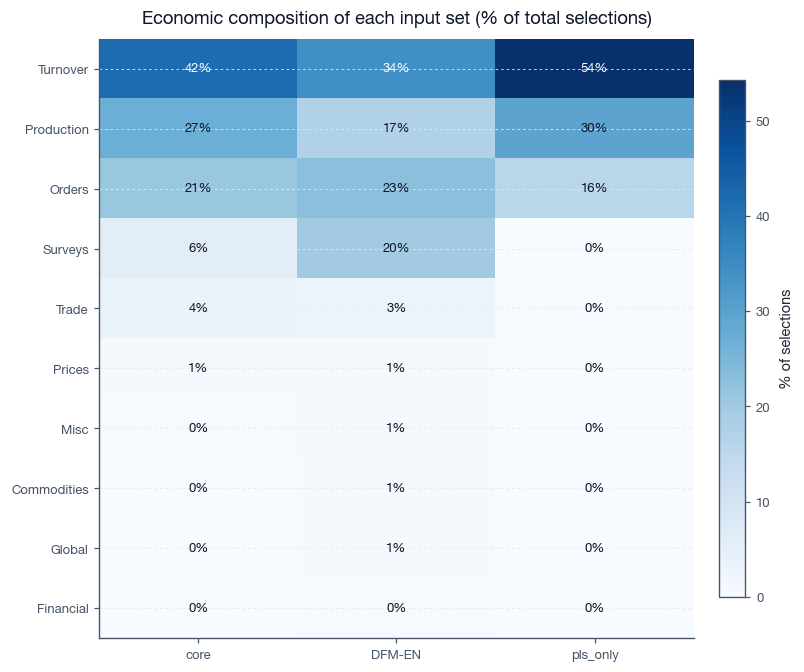

In [10]:
_meta = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=['id', 'category']).set_index('id')
npl.fig_composition_heatmap(
    selection_matrices, _meta,
    save=FIG_DIR / '05_composition_heatmap.png',
);


### 5e. Pairwise Diebold–Mariano matrix

Pairwise DM $p$-values among the models loaded in this notebook (DFM-EN, AR(1), RW, and SV if present). The thesis 11-model matrix is written by `build_unified_evaluation.py`.


In [11]:
# Full pairwise DM matrix (p-values, squared-error loss).
names = list(all_results.keys())
dm_mat = pd.DataFrame(np.eye(len(names)), index=names, columns=names) * np.nan
for a in names:
    for b in names:
        if a == b:
            continue
        e_a, e_b = align_forecast_errors(
            all_results[a], all_results[b], month_in_quarter=HEADLINE_MIQ
        )
        dm_mat.loc[a, b] = diebold_mariano_test(e_a, e_b)['p_value']
dm_mat.round(3).to_csv(_tp.DM_TABLE_CSV)
dm_mat.round(3)

,en_only,core,pls_only,RW,AR1,SV_k2
en_only,NaN,0.826,0.112,0.173,0.183,0.172
core,0.826,NaN,0.259,0.173,0.186,0.770
pls_only,0.112,0.259,NaN,0.178,0.192,0.105
RW,0.173,0.173,0.178,NaN,0.257,0.172
AR1,0.183,0.186,0.192,0.257,NaN,0.183
SV_k2,0.172,0.770,0.105,0.172,0.183,NaN


## 6. Category contributions (DFM-EN, 2017–2025)

ifoCAST-style decomposition: monthly M1/M2/M3 re-fits; contributions by indicator category.

* Cached panel: `category_contribs_en_2017_2025.parquet`
* Static heatmap + four interactive HTML panels under `FIG_DIR`


In [12]:
# Build or load cached category contributions (M1/M2/M3, 2017-01 – 2025-12).
meta = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=['id', 'category']).set_index('id')
contrib_cache_df = npl.run_category_contrib_panel(
    selection_matrix=selection_matrices['en_only'],
    X_monthly=X_monthly,
    y_quarterly=y_quarterly,
    meta=meta,
    quarterly_origins=quarterly_origins,
    pub_lag_map=pub_lag_map,
    k_factors=K_FACTORS,
    factor_order=FACTOR_ORDER,
    idiosyncratic_ar1=True,
    maxiter=200,
    m_start='2017-01',
    m_end='2025-12',
    cache_path=_tp.CATEGORY_CONTRIB_CACHE_PARQUET,
    force_rerun=FORCE_RERUN_CONTRIB,
    verbose=True,
)
print(f'Cached origins: {contrib_cache_df["monthly_origin"].nunique()}')


Loaded category contributions from category_contribs_en_2017_2025.parquet
Cached origins: 108


### 6b. Interactive contribution panels

Four sub-period HTML panels (2017–2019, 2020–2021, 2022–2023, 2024–2025).


In [13]:
# Four interactive panels (monthly x-axis); HTML saved under FIG_DIR.
CONTRIB_PERIODS = [
    ('2017-01', '2019-12', '2017_2019'),
    ('2020-01', '2021-12', '2020_2021'),
    ('2022-01', '2023-12', '2022_2023'),
    ('2024-01', '2025-12', '2024_2025'),
]
contrib_figs = npl.fig_category_contrib_period_panels(
    cache_df=contrib_cache_df,
    periods=CONTRIB_PERIODS,
    fig_dir=FIG_DIR,
    base_title='DFM-EN: Category Contributions by Forecast Origin',
)
# HTML panels written under FIG_DIR (see contrib_figs paths)


## 7. Integrated DFM-SV (*k* = 2)

Two-step overlay on DFM-EN: AR(1) log-volatility on factor VAR innovations (Kim, Shephard & Chib 1998; NumPyro NUTS), then the Kalman smoother is re-run with time-varying factor-innovation covariance *Q_t*. The **point** nowcast can differ from DFM-EN (full-sample RMSFE 0.781 against 0.784). This is not a post-hoc rescaling of intervals.

Sampler settings (thesis appendix): 500 warm-up + 1,000 retained draws per factor and origin, target acceptance 0.85.


In [14]:
# Integrated DFM-SV-k2 on EN inputs (headline distributional model)
from german_gdp_nowcasting.models.dfm.dfm_sv_integrated import (
    run_actpn_nowcast_loop_sv_integrated,
)
SV_K_FACTORS = 2
if _needs_run_sv(_tp.ACTPN_SV_RESULTS_K2_CSV):
    sv_k2_df = run_actpn_nowcast_loop_sv_integrated(
        selection_matrix=selection_matrices[HEADLINE_INPUT_SET],
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        quarterly_origins=quarterly_origins,
        factor_order=FACTOR_ORDER,
        idiosyncratic_ar1=True,
        maxiter=200,
        k_factors=SV_K_FACTORS,
        pub_lag_map=pub_lag_map,
        num_warmup=500,
        num_samples=1000,
        credibility=0.9,
        rng_seed=42,
        n_iter=1,
        save_path=_tp.ACTPN_SV_RESULTS_K2_CSV,
        verbose=False,
    )
else:
    sv_k2_df = _load_nowcast_csv(_tp.ACTPN_SV_RESULTS_K2_CSV)
print(
    f'DFM-SV-k2  RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(sv_k2_df, month_in_quarter=HEADLINE_MIQ):.4f}'
    f'  |  pooled M1-M3 = {compute_rmsfe(sv_k2_df):.4f}'
)
sv_k2_df.tail()


DFM-SV-k2  RMSFE M3 = 0.7808  |  pooled M1-M3 = 1.4040


,quarter,month_in_quarter,n_indicators,k_factors,nowcast,nowcast_baseline,point_shift,actual,error,ci_lower_90,ci_upper_90,rel_vol,rel_vol_target,sigma_em
monthly_origin,,,,,,,,,,,,,,
2025-08,2025Q3,2,60,2,0.102870,0.100713,0.002157,0.000000,0.102870,-0.925984,1.131724,1.0,0.651877,0.625499
2025-09,2025Q3,3,60,2,0.191083,0.191265,-0.000182,0.000000,0.191083,-0.843243,1.225409,1.0,0.686636,0.628826
2025-10,2025Q4,1,60,2,0.156090,0.155359,0.000731,0.314931,-0.158841,-0.772890,1.085070,1.0,0.717270,0.564780
2025-11,2025Q4,2,60,2,0.105934,0.105654,0.000280,0.314931,-0.208997,-0.843351,1.055218,1.0,0.881106,0.577124
2025-12,2025Q4,3,60,2,0.272939,0.272600,0.000340,0.314931,-0.041992,-0.681715,1.227593,1.0,0.902468,0.580388


### 7b. Interval calibration

Nominal 90% intervals. Full-sample coverage 53 of 60 (88.3%), mean width 1.624 pp, mean CRPS 0.357. That average is 97.2% before COVID, 25.0% during it (six of eight pandemic outcomes miss) and 100% afterwards. Pooled coverage is not evidence that the bands are honest in 2020.


,RMSFE,coverage_empirical,coverage_nominal,mean_width,CRPS
model,,,,,
SV_k2,0.7808,0.883,0.9,1.6242,0.3574


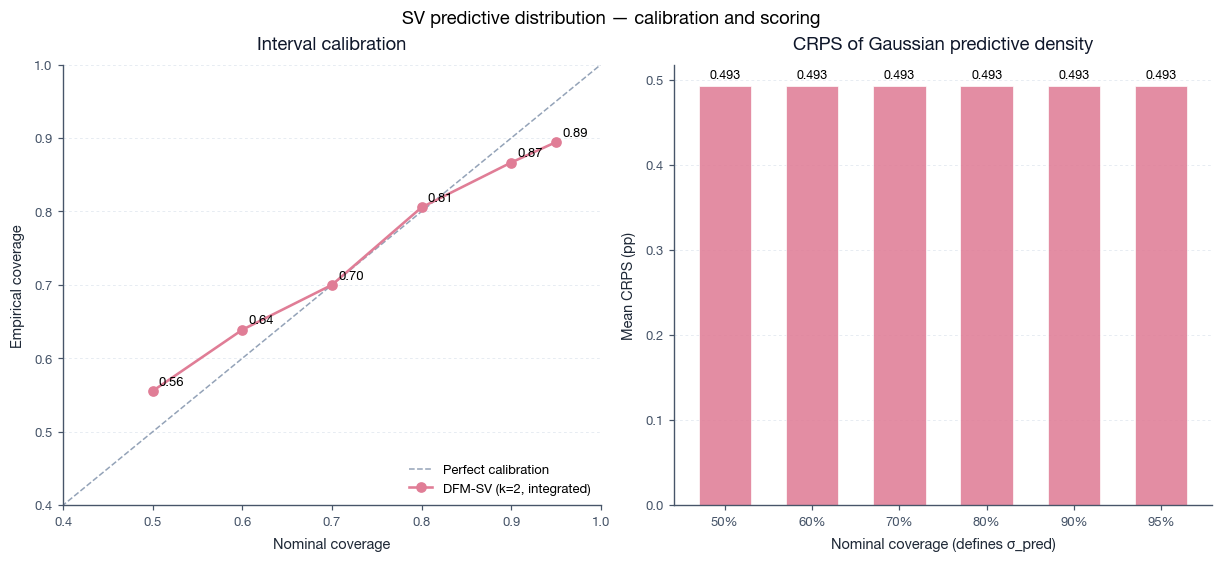

In [15]:
# Interval calibration table + calibration/CRPS figure (headline DFM-SV-k2)
sv_cal = build_interval_calibration_table(
    {'SV_k2': sv_k2_df},
    eval_start=EVAL_START,
    eval_end=EVAL_END,
    credibility=0.9,
)
display(sv_cal)
npl.fig_sv_calibration(
    sv_k2_df,
    model_label=npl.MODEL_LABELS.get('SV_k2', 'DFM-SV (k=2, integrated)'),
    save=FIG_DIR / '09_sv_comparison.png',
);


### 7c. Point-shift diagnostic

Integrated SV re-smooths with *Q_t*, so the point nowcast is allowed to differ from DFM-EN. Shifts concentrate in high-volatility episodes. A comment that the two point forecasts must coincide describes the retired two-stage Bayesian SV, not this specification.


In [16]:
# Integrated SV: point nowcast may differ from DFM-EN (time-varying Q_t).
_shift = sv_k2_df['point_shift'].abs().dropna() if 'point_shift' in sv_k2_df.columns else pd.Series(dtype=float)
if len(_shift):
    print(f'  mean |Δpoint| = {_shift.mean():.4f} pp  |  max = {_shift.max():.4f} pp')
else:
    print('  [INFO] point_shift column not available — re-run §7 with integrated SV.')


  mean |Δpoint| = 0.0037 pp  |  max = 0.0574 pp


### 7d. Fan chart

`11_nowcast_fan_sv90.png`: M3 nowcast with 90% intervals. The band follows a persistent volatility state: still about 1.26 pp wide in 2020Q1 (misses −2.25) and about 45% above its pre-COVID average after 2022 (mean half-width 1.03 pp against a target standard deviation of 0.187).


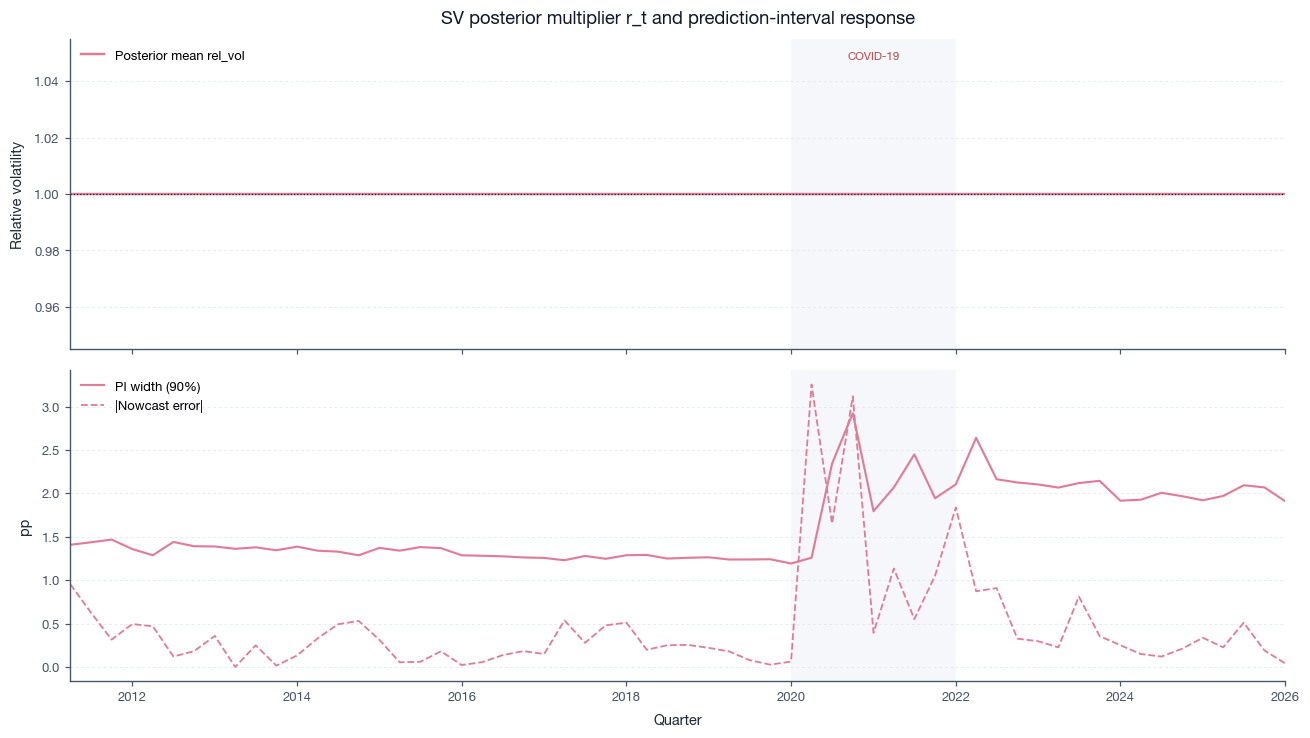

In [17]:
# Headline distributional model: integrated DFM-SV with k=2.
sv_df = sv_k2_df
npl.fig_sv_volatility(sv_df, save=FIG_DIR / '06_sv_volatility.png');


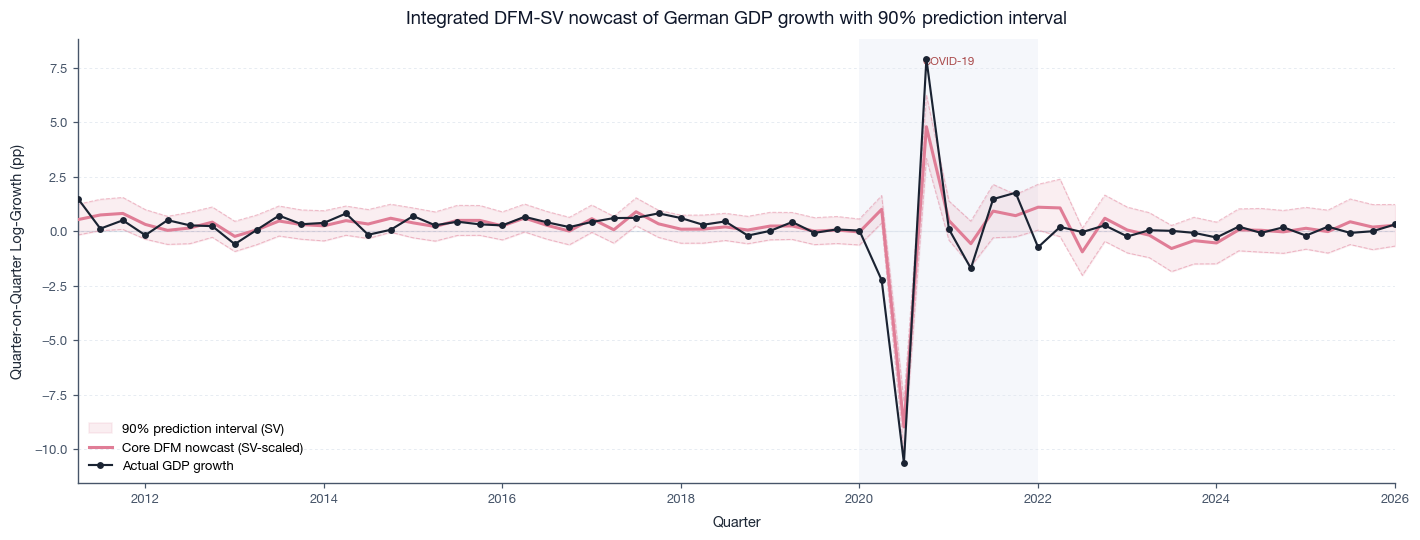

In [18]:
# DFM-SV-k2 nowcast with 90% time-varying prediction interval.
# The shaded band widens automatically in turbulent periods (COVID 2020) because it
# is driven by the posterior SV multiplier r_t — not by a constant sigma.
npl.fig_nowcast_fan(sv_df, credibility=0.90, save=FIG_DIR / '11_nowcast_fan_sv90.png');


## 8. Rest of Part II (CLI)

| Script | Specification |
|---|---|
| `scripts/pipelines/dfm/run_ifocast_benchmark.py` | Frozen 19-indicator ifoCAST set |
| `scripts/pipelines/dfm/run_blockbalanced_benchmark.py` | Block-balanced *k* = 20 (one series per category) |
| `scripts/pipelines/dfm/run_ifocast_regime_combo.py` | Equal-weight average of DFM-EN, block-balanced and ifoCAST |
| `scripts/pipelines/dfm/run_tvp_benchmark.py` | Drifting factor-to-GDP bridge |
| `scripts/pipelines/dfm/rerun_sv_integrated.py` | Refresh integrated DFM-SV |
| `scripts/pipelines/dfm/run_post_covid_benchmarks.py` | Rolling and intercept-corrected AR(1) |
| `scripts/pipelines/mlp/mlp_factor_comparison.py` | MLP-Factor (same EN factors, non-linear map) |
| `scripts/pipelines/dfm/run_horizon_profile.py` | M1–M3 profiles by regime |
| `scripts/pipelines/dfm/run_release_block_counterfactual.py` | Post-COVID hard vs non-hard update |
| `scripts/pipelines/dfm/build_unified_evaluation.py` | RMSFE, DM, MCS, Mincer–Zarnowitz |
| `scripts/pipelines/dfm/run_all_thesis_figures.py` | Thesis figures |

The release-block experiment is a fitted-model accounting identity for 2022Q1–2025Q4 (*N* = 16). It does not show that official hard releases are generally harmful.
